In [1]:
import spot
from spot.jupyter import display_inline
spot.setup()

Work in progress for a representation of EL-automata (a.k.a. `twa` in Spot) using MTBDDs.

# Transition-based variant (mtdtwa)

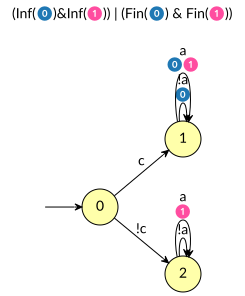

In [2]:
a = spot.translate("GFa <-> c", "generic", "deterministic")
a

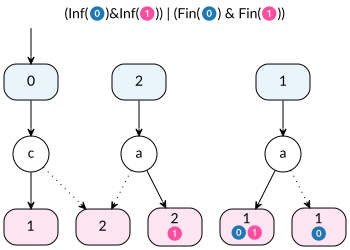

In [3]:
m = spot.dtwa_to_mtdtwa(a)
m

Each terminal stores an integer that allows to retrieve the data presented in the leaves above: a set of colors, and a destination state.

In [4]:
for i, d in enumerate(m.terminal_data_map):
    print(f"terminal_data_map[{i}] = {d}")

terminal_data_map[0] = (spot.mark_t([]), 1)
terminal_data_map[1] = (spot.mark_t([]), 2)
terminal_data_map[2] = (spot.mark_t([0]), 1)
terminal_data_map[3] = (spot.mark_t([0, 1]), 1)
terminal_data_map[4] = (spot.mark_t([1]), 2)


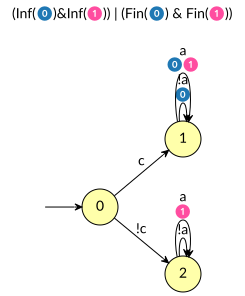

In [5]:
m.as_twa()

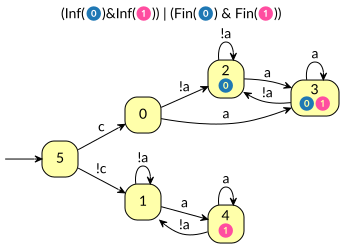

In [6]:
m.as_twa(True)

# State-based variant (mtdswa)

This version is closer Mona's DFA representation.  An `mtdswa` is just a pair of array indexed by state numbers.  The value of `states[i]` is an MTBDD encoding the successors states of state `i`, with terminal containing state indices.  The value of `colors[i]` gives the set of colors associated to state `i`.  The set of MTBDD nodes needed to represent a `mtdswa` is not bigger than the one used to represent an `mtdtwa` as states that have different colors but behave the same will share their MTBDD.   This representation seems much easier to work with.

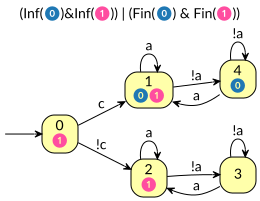

In [7]:
a2 = spot.sbacc(a)
a2

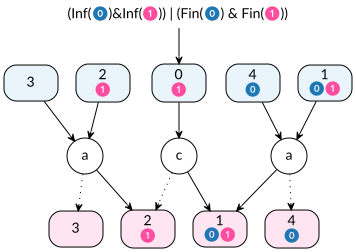

In [8]:
m2 = spot.dtwa_to_mtdswa(a2)
display(m2)

In [9]:
for i, d in enumerate(m2.colors):
    print(f"colors[{i}] = {d}")

colors[0] = {1}
colors[1] = {0,1}
colors[2] = {1}
colors[3] = {}
colors[4] = {0}


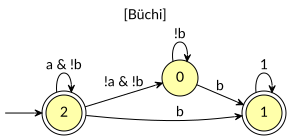

In [10]:
a3 = spot.translate("Ga | Fb")
a3

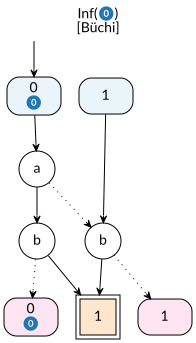

In [11]:
m3 = spot.dtwa_to_mtdswa(a3)
m3

In [12]:
display_inline(m3.as_twa(), m3.as_twa(True))

In [13]:
display_inline(m2.as_twa(), m2.as_twa(True))

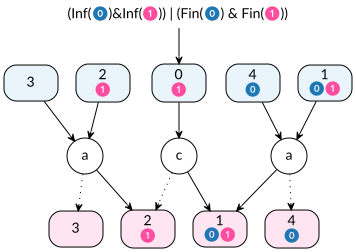

In [14]:
m2

# SCC computations

The `scc_vector` assigne each state to the index of a maximal SCC ordered topologically (each SCC can only reach SCC with smaller indices).

The computation is performed in Linear time by considering the mtdswa as an oriented graph.  Passing option 's' to `show()` will highlight non-trivial SCCs (including their states and MTBDD nodes).

In [15]:
spot.scc_vector(m2)

(2, 1, 0, 0, 1)

In [16]:
spot.scc_vector(m3)

(1, 0)

In [17]:
m2.show("s")

In [18]:
m3.show("s")

In [19]:
a = spot.translate("(a U b) | XG(c)", "det")
m4 = spot.dtwa_to_mtdswa(a)
print(spot.scc_vector(m4))
m4.show('s')

(3, 1, 0, 2)


In [20]:
a = spot.translate("(a U b) & GFa & GFb & FGc", "det", "sbacc", "gen")
m5 = spot.dtwa_to_mtdswa(a)
m5.show('s')

**TODO**: The linking above is not optimal.  Since all states 1,2,3,4,5 recognize the same language, it would be better to always jump on the same sate when entering this SCC.  That way the two transient "b" node above false could be merged.  Currently we don't care too much because those nodes were converted from an explicit representation.  However when we start building translating LTL to mtdswa directly, we can probably do better.

The `false` and `true` automata don't display very well because they have to introduce a state that points the constant.

In [21]:
a = spot.translate("true", "det")
m5 = spot.dtwa_to_mtdswa(a)
print(spot.scc_vector(m5))
m5.show('s')

(0,)


# Translation from obligation formula to Deterministic Weak BA 

represented as MTDSWA

In [22]:
t1 = spot.obligation_to_mtdswa('a W b U c')
t1.show('s')

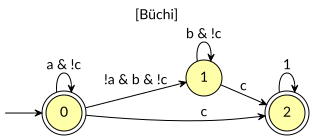

In [23]:
t1.as_twa(True)

In [24]:
t2 = spot.obligation_to_mtdswa('Fa & Fb & Fc')
t2.show('s')

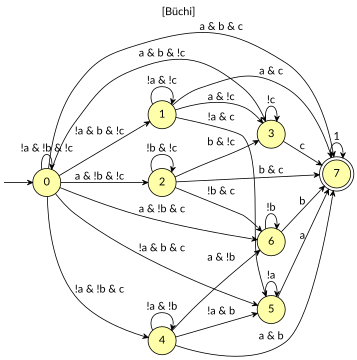

In [25]:
t2.as_twa(True)

In [26]:
t3 = spot.obligation_to_mtdswa('G(p1 <-> X!p1) | F(p0 & Xp1)')
t3.show('s')

In [27]:
t3.as_twa(True).show('.s')

Here is a list of obligation formulas to check that the new translation is equivalent to the old one.

In [28]:
obligations = ['Gp',
               'Fr -> (!p U r)',
               '(!r U (p & !r)) | G!r',
               'Fr -> ((!p & !r) U (r | ((p & !r) U (r | ((!p & !r) U (r | ((p & !r) U (r | (!p U r)))))))))',
               'Fr -> (p U r)',
               'G(q -> Gp)',
               'Fr -> (!p U (r | s))',
               'Fr -> ((p -> (!r U (!r & s))) U r)',
               'Fp -> (!p U (!p & s & X(!p U t)))',
               'Fr -> (!p U (r | (!p & s & X(!p U t))))',
               'F(s & XFt) -> (!s U p)',
               'Fr -> (!(!r & s & X(!r U (!r & t))) U (p | r))',
               'Fr -> ((p -> (!r U (!r & s & X(!r U t)))) U r)',
               'Fr -> ((p -> (!r U (!r & s & !z & X((!r & !z) U t)))) U r)',
               'Fp',
               'G!q | F(q & Fp)',
               '(!p U s) | Gp',
               'Fr -> (((s & X(!r U t)) -> X(!r U (t & Fp))) U r)',
               'G(p1 <-> X!p1) | F(p0 & Xp1)']
for obl in obligations:
    f = spot.formula(obl)
    t1 = spot.obligation_to_mtdswa(f).as_twa(True)    # non-minimized, via MTBDDs
    t2 = f.translate('deterministic')                 # minimized, via the historical and explicit construction 
    print(t1.num_states(), t2.num_states(), spot.are_equivalent(t1, t2), f)

1 1 True Gp
3 3 True (!p U r) | G!r
2 2 True p R !r
7 7 True G!r | ((!p & !r) U ((p & !r) U ((!p & !r) U ((p & !r) U (!p U r)))))
3 3 True (p U r) | G!r
2 2 True G(!q | Gp)
3 3 True (!p U (r | s)) | G!r
3 3 True G!r | ((!p | (s M !r)) U r)
3 3 True (s & X(!p U t)) R !p
4 4 True (!p U (r | (!p & s & X(!p U t)))) | G!r
3 3 True (!s U p) | G(!s | XG!t)
5 4 True G!r | ((!s | X(!t W r)) U (p | r))
4 4 True G!r | ((!p | ((s & X(!r U t)) M !r)) U r)
4 4 True G!r | ((!p | ((s & !z & X((!r & !z) U t)) M !r)) U r)
2 2 True Fp
3 3 True !q W (q & Fp)
4 4 True (!p U s) | Gp
6 6 True G!r | ((!s | X((!r U (t & Fp)) | (r R !t))) U r)
7 7 True F(p0 & Xp1) | G((p1 & X!p1) | (!p1 & Xp1))


In [29]:
f = spot.formula('G(p1 <-> X!p1) | F(p0 & Xp1)')

In [30]:
spot.obligation_to_mtdswa(f).show('s')

Let's look at he only case where the new translation produce one extra state compared to the reference implementation (which is already minimized).

In [31]:
f = spot.formula('G!r | ((!s | X(!t W r)) U (p | r))')

In [32]:
a = spot.obligation_to_mtdswa(f)
a.show('s')

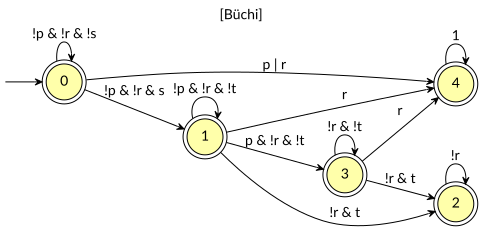

In [33]:
b1 = a.as_twa(True)
b1

(State 1 and 3 can be merged.)

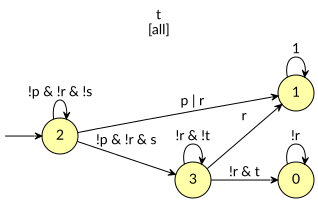

In [34]:
b2 = f.translate('deterministic')
b2

In [35]:
spot.are_equivalent(b1, b2)

True

# Minimization

The minimization currently forces the `bddtrue` and `bddfalse` terminals in separate classes.  So, for instance, if you build a MTDFA that contains a `bddtrue` terminal, and another accepting state that loops over itself with label "true", these two states won't be merged.   The minimization for `mtdfa` used to deal with this case, but that made the code a bit more complex.  In practice, the `bddtrue` and `bddfalse` terminals are only useful during the recursive translation, where they help shortcut BDD operations, but they are more annoying to deal with afterwards.  Hence this implementation of the minimization does not make any effort regarding those.

Next section will show how to change between constant-based (`bddtrue`, `bddfalse`), or state-based representations of sinks.  Therefore, fore precise minimization, you should call `a.sinks_as_states()` before `spot.minimize_mtdswa(a)`.

In [36]:
am = spot.minimize_mtdswa(a)
am.show('s')

In [37]:
spot.are_equivalent(a.as_twa(), am.as_twa())

True

# Converting sinks to states or constants

In [38]:
am.sinks_as_states(); am.show('s')

In [39]:
am.sinks_as_constants(); am.show('s')

In [40]:
a1 = spot.obligation_to_mtdswa('Ga')

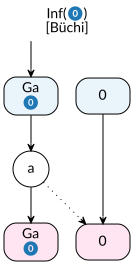

In [41]:
# This one requires changing the acceptance condition
a1.sinks_as_states(); a1

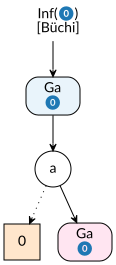

In [42]:
# Comming back to constants do the change the acceptance condition
a1.sinks_as_constants(); a1

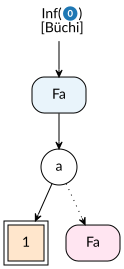

In [43]:
a2 = spot.obligation_to_mtdswa('Fa'); a2

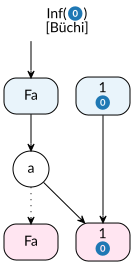

In [44]:
a2.sinks_as_states(); a2

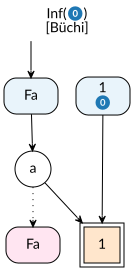

In [45]:
# The optional argument asks to uses constants, but without removing the original sink states.
a2.sinks_as_constants(True); a2

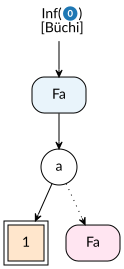

In [46]:
a2.sinks_as_constants(); a2

# Game interpretation

In [47]:
am.set_controllable_variables(['s', 'p'])
am.show('s')